# Borrower Risk Intelligence System
## Notebook 2 — Feature Engineering

**Objective:** Transform raw borrower data into meaningful signals grounded in lending intuition and EDA findings.

---

**Contents**
1. Setup
2. Drop high-missing columns
3. Feature engineering
4. Validate features against target
5. Impute remaining missing values
6. Encode categoricals
7. Correlation check
8. Train / test split
9. Save to Drive
10. Summary

## 1 — Setup

Set `FIRST_TIME = True` on first run — downloads dataset from Kaggle and saves to Drive. Set to `False` for all future sessions.

In [18]:
FIRST_TIME = False

import subprocess
subprocess.run(['pip', 'install', 'kaggle', '-q'], check=True)

from google.colab import drive, files
import os

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/borrower-risk-intelligence/data'
os.makedirs(DATA_DIR, exist_ok=True)
CSV_PATH = f'{DATA_DIR}/application_train.csv'

if FIRST_TIME:
    files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.system('mv kaggle.json /root/.kaggle/')
    os.system('chmod 600 /root/.kaggle/kaggle.json')
    os.system('kaggle competitions download -c home-credit-default-risk -p /content/')
    os.system('unzip -q /content/home-credit-default-risk.zip -d /content/')
    os.system(f'cp /content/application_train.csv {CSV_PATH}')
    print(f'Saved to {CSV_PATH}')
else:
    print(f'Loading from Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading from Drive


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

df = pd.read_csv(CSV_PATH)
print(f'Rows: {df.shape[0]:,}  Features: {df.shape[1]}')

Rows: 307,511  Features: 122


## 2 — Drop High-Missing Columns

41 features had >50% missing values in EDA. Imputing columns this sparse introduces noise.

In [20]:
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()

print(f'Dropping {len(cols_to_drop)} columns')
df.drop(columns=cols_to_drop, inplace=True)
print(f'Remaining features: {df.shape[1]}')

Dropping 41 columns
Remaining features: 81


## 3 — Feature Engineering

Features designed from lending intuition, not statistical iteration. A model trained on `AMT_CREDIT` and `AMT_INCOME_TOTAL` as separate columns cannot learn their relationship — encoding it as a ratio gives the model a direct signal.

In [21]:
# Stored as negative integers in the dataset — converting to years
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)

# 365243 is a placeholder value for pensioners in DAYS_EMPLOYED
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'] / 365).round(1)

print(df[['AGE_YEARS', 'EMPLOYMENT_YEARS']].describe().round(1).T)

                     count  mean   std   min   25%   50%   75%   max
AGE_YEARS         307511.0  43.4  12.0  20.0  34.0  43.0  53.0  69.0
EMPLOYMENT_YEARS  252137.0   6.5   6.4   0.0   2.1   4.5   8.7  49.1


In [22]:
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Borrowers financing 100% of goods price have no skin in the game
df['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
df['ANNUITY_CREDIT_RATIO'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, 1)

ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
              'CREDIT_GOODS_RATIO', 'ANNUITY_CREDIT_RATIO', 'INCOME_PER_PERSON']
print(df[ratio_cols].describe().round(3).T)

                         count       mean         std       min        25%  \
CREDIT_INCOME_RATIO   307511.0      3.958       2.690     0.005      2.019   
ANNUITY_INCOME_RATIO  307499.0      0.181       0.095     0.000      0.115   
CREDIT_GOODS_RATIO    307233.0      1.123       0.124     0.150      1.000   
ANNUITY_CREDIT_RATIO  307499.0      0.054       0.022     0.022      0.037   
INCOME_PER_PERSON     307509.0  93105.880  101373.363  2812.500  47250.000   

                            50%         75%           max  
CREDIT_INCOME_RATIO       3.265       5.160  8.473700e+01  
ANNUITY_INCOME_RATIO      0.163       0.229  1.876000e+00  
CREDIT_GOODS_RATIO        1.119       1.198  6.000000e+00  
ANNUITY_CREDIT_RATIO      0.050       0.064  1.240000e-01  
INCOME_PER_PERSON     75000.000  112500.000  3.900000e+07  


In [23]:
all_ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_cols = [c for c in all_ext_cols if c in df.columns]
print(f'EXT_SOURCE columns available: {ext_cols}')

if ext_cols:
    df['EXT_SOURCE_MEAN']    = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_MIN']     = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_PRODUCT'] = df[ext_cols].prod(axis=1)
    print(df[['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PRODUCT']].describe().round(3).T)

EXT_SOURCE columns available: ['EXT_SOURCE_2', 'EXT_SOURCE_3']
                       count   mean    std  min    25%    50%    75%    max
EXT_SOURCE_MEAN     307281.0  0.511  0.156  0.0  0.414  0.532  0.631  0.863
EXT_SOURCE_MIN      307281.0  0.430  0.190  0.0  0.283  0.449  0.586  0.863
EXT_SOURCE_PRODUCT  307511.0  0.315  0.185  0.0  0.168  0.299  0.441  1.000


In [24]:
# Absence of data is itself a signal in lending
all_flag_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE',
                 'AMT_ANNUITY', 'EMPLOYMENT_YEARS']
flag_cols = [c for c in all_flag_cols if c in df.columns]

for col in flag_cols:
    df[f'{col}_MISSING'] = df[col].isnull().astype(int)
    print(f'{col}_MISSING: {df[f"{col}_MISSING"].sum():,} flagged')

EXT_SOURCE_3_MISSING: 60,965 flagged
AMT_GOODS_PRICE_MISSING: 278 flagged
AMT_ANNUITY_MISSING: 12 flagged
EMPLOYMENT_YEARS_MISSING: 55,374 flagged


In [25]:
doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT')]
df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)
print(df['DOCUMENT_COUNT'].value_counts().head(6))

DOCUMENT_COUNT
1    270056
0     29549
2      7742
3       163
4         1
Name: count, dtype: int64


In [26]:
df['AGE_BUCKET'] = pd.cut(df['AGE_YEARS'],
                           bins=[0, 25, 35, 45, 55, 100],
                           labels=[0, 1, 2, 3, 4]).astype(float)
print(df['AGE_BUCKET'].value_counts().sort_index())

AGE_BUCKET
0.0    16318
1.0    75925
2.0    83677
3.0    69501
4.0    62090
Name: count, dtype: int64


## 4 — Validate Features Against Target

In [27]:
validate_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'INCOME_PER_PERSON'
]
if 'EXT_SOURCE_MEAN' in df.columns:
    validate_features.append('EXT_SOURCE_MEAN')

comp = df.groupby('TARGET')[validate_features].mean().T
comp.columns = ['Non-Default', 'Default']
comp['Diff %'] = ((comp['Default'] - comp['Non-Default'])
                  / comp['Non-Default'].abs() * 100).round(1)
comp['Separates?'] = comp['Diff %'].abs().apply(lambda x: 'YES' if x > 5 else 'WEAK')
print(comp.to_string())

                       Non-Default       Default  Diff % Separates?
CREDIT_INCOME_RATIO       3.963729      3.887438    -1.9       WEAK
ANNUITY_INCOME_RATIO      0.180530      0.185482     2.7       WEAK
CREDIT_GOODS_RATIO        1.120443      1.152056     2.8       WEAK
AGE_YEARS                43.713123     40.279960    -7.9        YES
EMPLOYMENT_YEARS          6.679780      4.972210   -25.6        YES
INCOME_PER_PERSON     93303.290305  90857.950745    -2.6       WEAK
EXT_SOURCE_MEAN           0.521066      0.400373   -23.2        YES


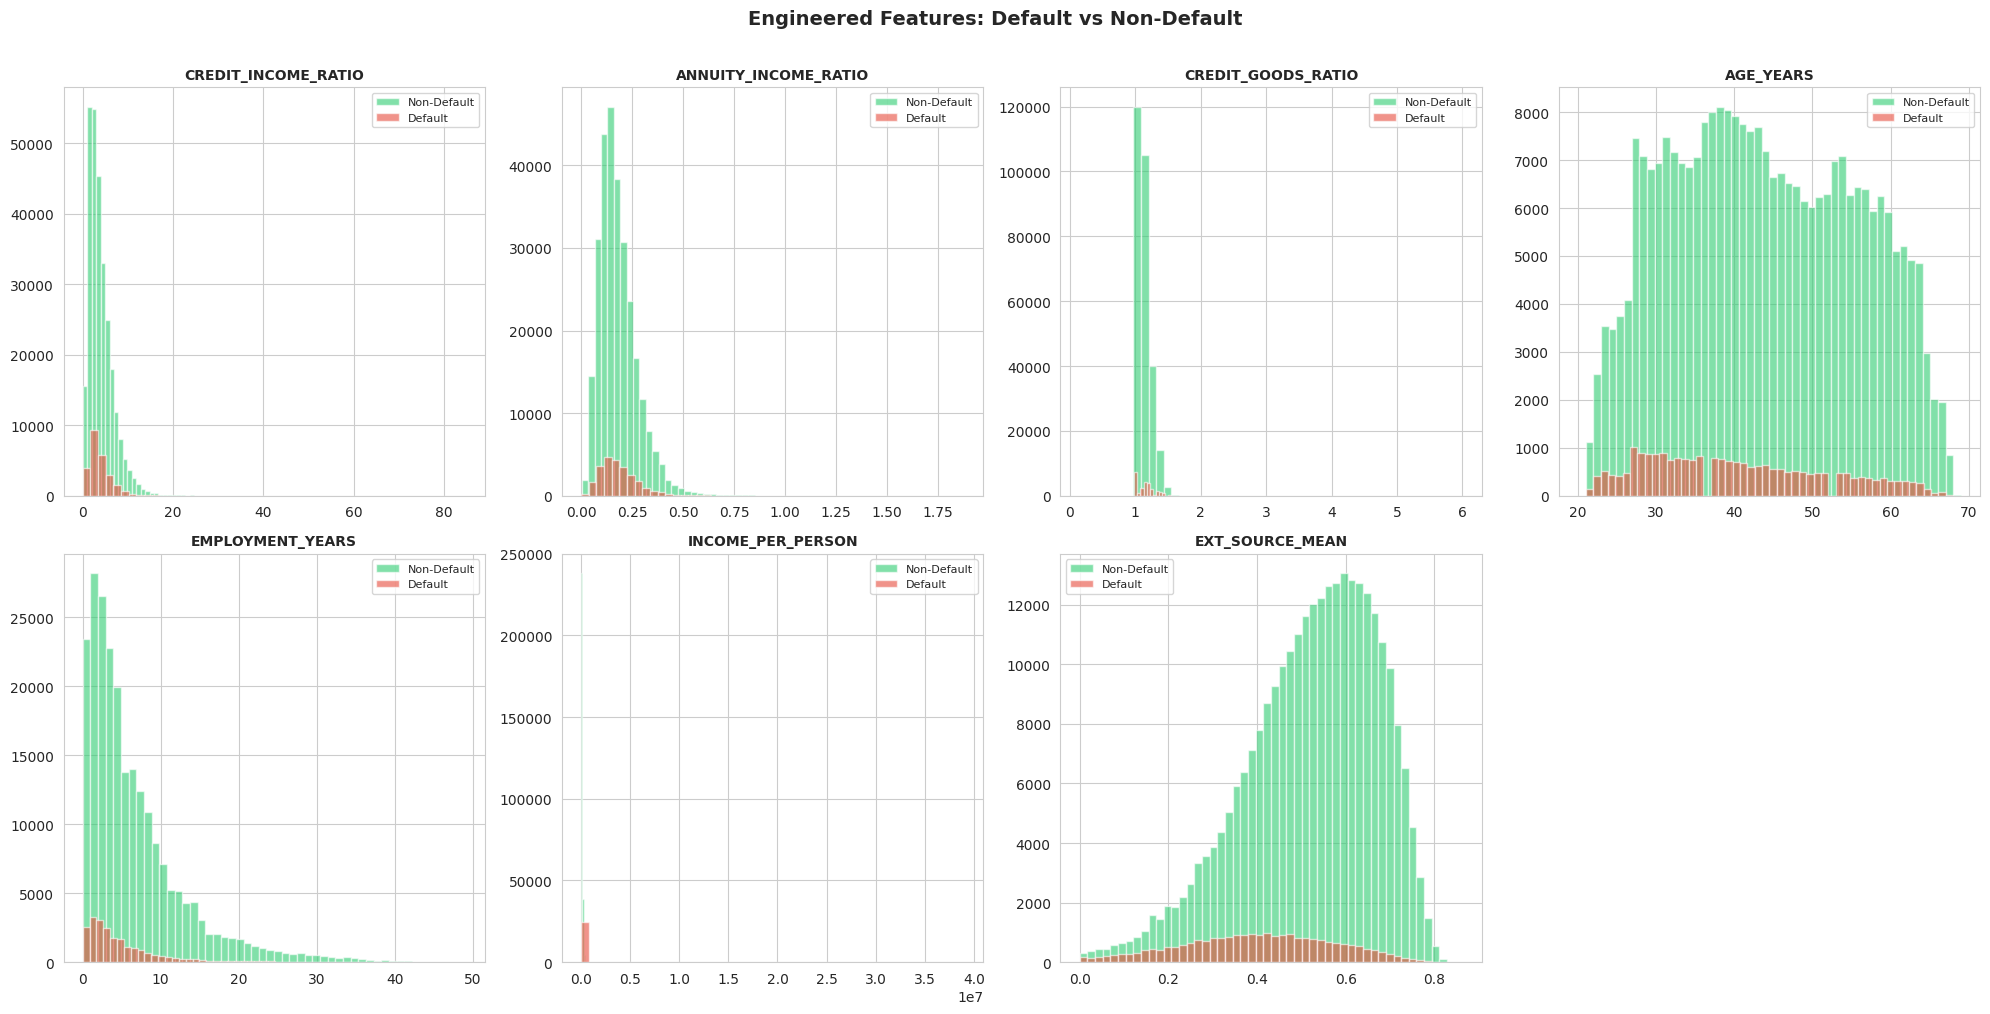

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(validate_features):
    df[df['TARGET']==0][feature].hist(bins=50, alpha=0.6, color='#2ecc71', label='Non-Default', ax=axes[i])
    df[df['TARGET']==1][feature].hist(bins=50, alpha=0.6, color='#e74c3c', label='Default', ax=axes[i])
    axes[i].set_title(feature, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engineered Features: Default vs Non-Default', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Impute Remaining Missing Values

Median imputation. Preferred over mean because income and credit distributions are right-skewed.

In [29]:
numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'TARGET']
missing_before = df[numerical_cols].isnull().sum().sum()

for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print(f'Missing before : {missing_before:,}')
print(f'Missing after  : {df[numerical_cols].isnull().sum().sum():,}')

Missing before : 1,484,140
Missing after  : 0


## 6 — Encode Categoricals

In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Encoding {len(categorical_cols)} categorical columns')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Done. Shape: {df.shape}')

Encoding 13 categorical columns
Done. Shape: (307511, 97)


## 7 — Correlation Check

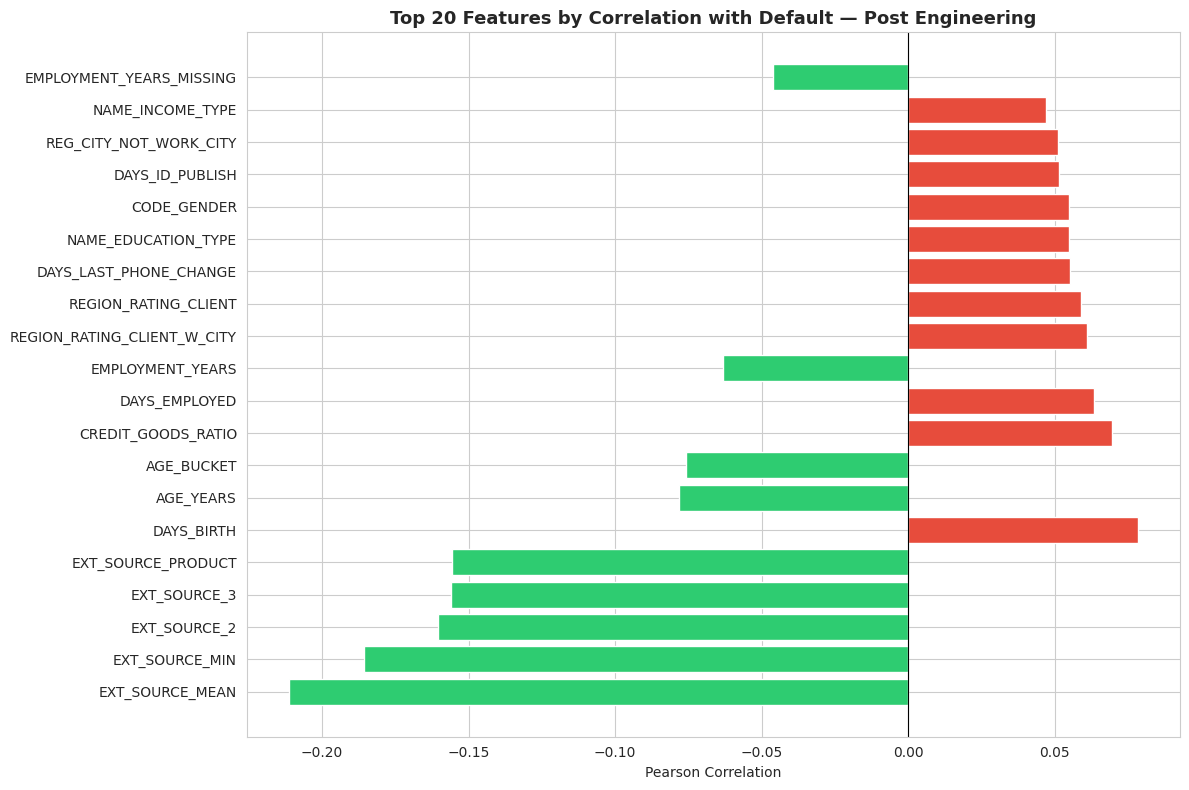

EXT_SOURCE_MEAN      -0.211190
EXT_SOURCE_MIN       -0.185683
EXT_SOURCE_2         -0.160295
EXT_SOURCE_3         -0.155892
EXT_SOURCE_PRODUCT   -0.155757
DAYS_BIRTH            0.078239
AGE_YEARS            -0.078234
AGE_BUCKET           -0.075660
CREDIT_GOODS_RATIO    0.069398
DAYS_EMPLOYED         0.063368


In [31]:
corr = df.corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)
top20 = corr.head(20)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top20.values]
plt.barh(top20.index, top20.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Features by Correlation with Default — Post Engineering', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/post_engineering_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(top20.head(10).to_string())

## 8 — Train / Test Split

In [32]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,}')
print(f'Test  : {X_test.shape[0]:,}')
print(f'\nClass balance (train):')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nDefault rate preserved: {y_train.mean():.3f}')

Train : 246,008
Test  : 61,503

Class balance (train):
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Default rate preserved: 0.081


## 9 — Save to Drive

In [33]:
X_train.to_csv(f'{DATA_DIR}/X_train.csv', index=False)
X_test.to_csv(f'{DATA_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{DATA_DIR}/y_train.csv', index=False)
y_test.to_csv(f'{DATA_DIR}/y_test.csv', index=False)

feature_list = X_train.columns.tolist()
with open(f'{DATA_DIR}/feature_list.pkl', 'wb') as f:
    pickle.dump(feature_list, f)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Features: {len(feature_list)}')
print(f'Saved to {DATA_DIR}')

X_train : (246008, 95)
X_test  : (61503, 95)
Features: 95
Saved to /content/drive/MyDrive/borrower-risk-intelligence/data


## 10 — Summary

In [34]:
print(f"""
FEATURE ENGINEERING SUMMARY

Dropped
  High-missing columns (>50%)  : {len(cols_to_drop)}

Created
  Age / employment in years    : AGE_YEARS, EMPLOYMENT_YEARS
  Financial stress ratios      : CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO,
                                  CREDIT_GOODS_RATIO, ANNUITY_CREDIT_RATIO
  Income per family member     : INCOME_PER_PERSON
  External credit aggregates   : EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_PRODUCT
  Missingness flags            : {len(flag_cols)} binary indicators
  Document count               : DOCUMENT_COUNT
  Age bucket                   : AGE_BUCKET

Processing
  Median imputation            : all remaining numerical NaNs
  Label encoding               : {len(categorical_cols)} columns
  Train / test split           : 80/20, stratified
  Class imbalance              : handled via scale_pos_weight in Notebook 3

Final
  Training rows                : {X_train.shape[0]:,}
  Test rows                    : {X_test.shape[0]:,}
  Features                     : {X_train.shape[1]}
  Default rate (train)         : {y_train.mean():.3f}
""")


FEATURE ENGINEERING SUMMARY

Dropped
  High-missing columns (>50%)  : 41

Created
  Age / employment in years    : AGE_YEARS, EMPLOYMENT_YEARS
  Financial stress ratios      : CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO,
                                  CREDIT_GOODS_RATIO, ANNUITY_CREDIT_RATIO
  Income per family member     : INCOME_PER_PERSON
  External credit aggregates   : EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_PRODUCT
  Missingness flags            : 4 binary indicators
  Document count               : DOCUMENT_COUNT
  Age bucket                   : AGE_BUCKET

Processing
  Median imputation            : all remaining numerical NaNs
  Label encoding               : 13 columns
  Train / test split           : 80/20, stratified
  Class imbalance              : handled via scale_pos_weight in Notebook 3

Final
  Training rows                : 246,008
  Test rows                    : 61,503
  Features                     : 95
  Default rate (train)         : 0.081

